# Phase 3 — Model Comparison, Confusion Matrix, Calibration, SHAP

Loads the saved winning model (CatBoost — see `docs/baseline_results.md`) and visualizes what `docs/baseline_results.md` reports in text form. No retraining happens here.

In [1]:
import sys
sys.path.insert(0, "../../backend")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from catboost import CatBoostClassifier
from sklearn.calibration import calibration_curve
from sklearn.metrics import confusion_matrix, precision_recall_curve

from app.models.classifier import build_classification_dataset, evaluate_classifier
from app.models.explain import compute_shap_values, shap_feature_importance
from app.models.feature_set import CATEGORICAL_FEATURES, NUMERIC_FEATURES

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)

features = pd.read_parquet("../../data/processed/features.parquet")
targets = pd.read_parquet("../../data/processed/targets.parquet")
split = build_classification_dataset(features, targets)
feature_cols = NUMERIC_FEATURES + CATEGORICAL_FEATURES

model = CatBoostClassifier()
model.load_model("../models/classifier_catboost.cbm")
print("Loaded CatBoost model. Test split:", len(split.test), "rows")


Loaded CatBoost model. Test split: 44767 rows


## 1. Test-set predictions + confusion matrix
Threshold fixed at the validation-chosen 0.30 (see baseline_results.md).

{'model': 'catboost_test', 'pr_auc': 0.8732, 'precision': 0.7341, 'recall': 0.9651, 'f1': 0.8339, 'brier_score': 0.1766, 'best_threshold': 0.3, 'n_samples': 44767, 'positive_rate': 0.7027, 'confusion_matrix': [[2310, 10999], [1098, 30360]]}


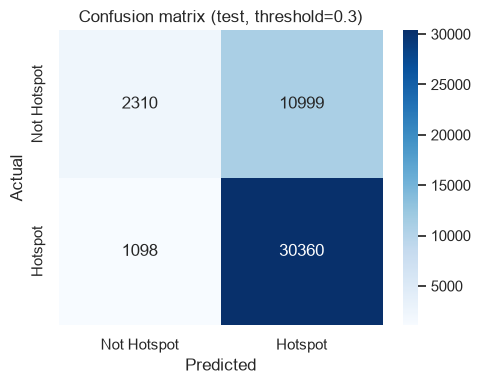

In [2]:
X_test = split.test[feature_cols]
y_test = split.test["target_hotspot_60m"].to_numpy()
proba_test = model.predict_proba(X_test)[:, 1]

THRESHOLD = 0.30
y_pred = (proba_test >= THRESHOLD).astype(int)
metrics = evaluate_classifier("catboost_test", y_test, proba_test, threshold=THRESHOLD)
print(metrics.to_dict())

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Hotspot", "Hotspot"], yticklabels=["Not Hotspot", "Hotspot"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion matrix (test, threshold={THRESHOLD})")
plt.tight_layout()
plt.show()


## 2. Precision-Recall curve
Shows the full precision/recall trade-off across thresholds, not just the single F1-optimal point used above.

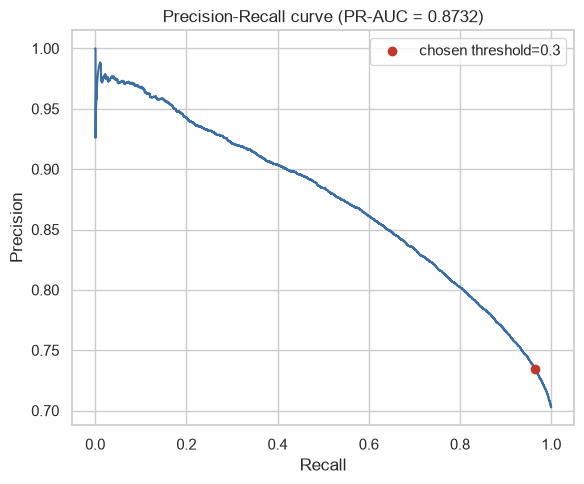

In [3]:
precisions, recalls, thresholds = precision_recall_curve(y_test, proba_test)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(recalls, precisions, color="#3b6ea5")
ax.scatter([metrics.recall], [metrics.precision], color="#c0392b", zorder=5,
           label=f"chosen threshold={THRESHOLD}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(f"Precision-Recall curve (PR-AUC = {metrics.pr_auc:.4f})")
ax.legend()
plt.tight_layout()
plt.show()


## 3. Calibration / reliability curve
If the model were perfectly calibrated, points would sit on the diagonal — a predicted probability of 0.7 should mean the event actually happens ~70% of the time.

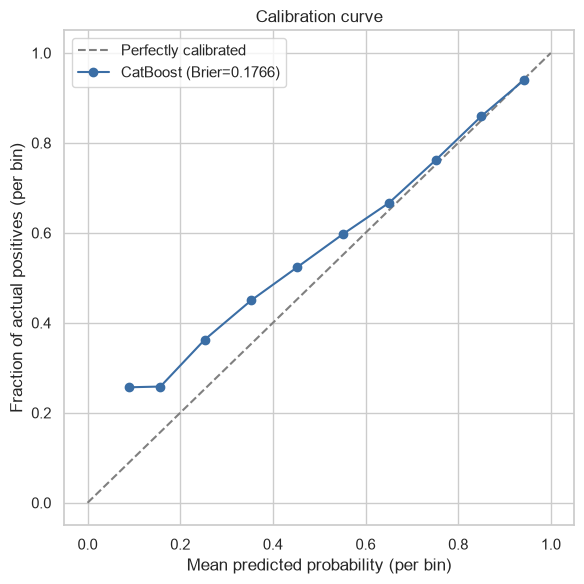

In [4]:
prob_true, prob_pred = calibration_curve(y_test, proba_test, n_bins=10)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")
ax.plot(prob_pred, prob_true, marker="o", color="#3b6ea5", label=f"CatBoost (Brier={metrics.brier_score:.4f})")
ax.set_xlabel("Mean predicted probability (per bin)")
ax.set_ylabel("Fraction of actual positives (per bin)")
ax.set_title("Calibration curve")
ax.legend()
plt.tight_layout()
plt.show()


## 4. SHAP summary plot
Global feature importance + direction of effect, on a sample of the validation set.

In [5]:
X_val = split.val[feature_cols]
shap_values, X_sample = compute_shap_values(model, X_val, max_samples=2000)
importance = shap_feature_importance(shap_values, feature_cols)
importance.head(15)


,feature,mean_abs_shap
0,h3_cell,0.433921
1,rolling_hotspot_intensity,0.237661
2,vehicle_type,0.138164
3,violations_last_15m,0.097867
4,hour_cos,0.085024
5,primary_offence_code,0.081220
6,violations_last_60m,0.058928
7,primary_violation_type,0.047035
8,center_code,0.042558
9,violation_density,0.041542


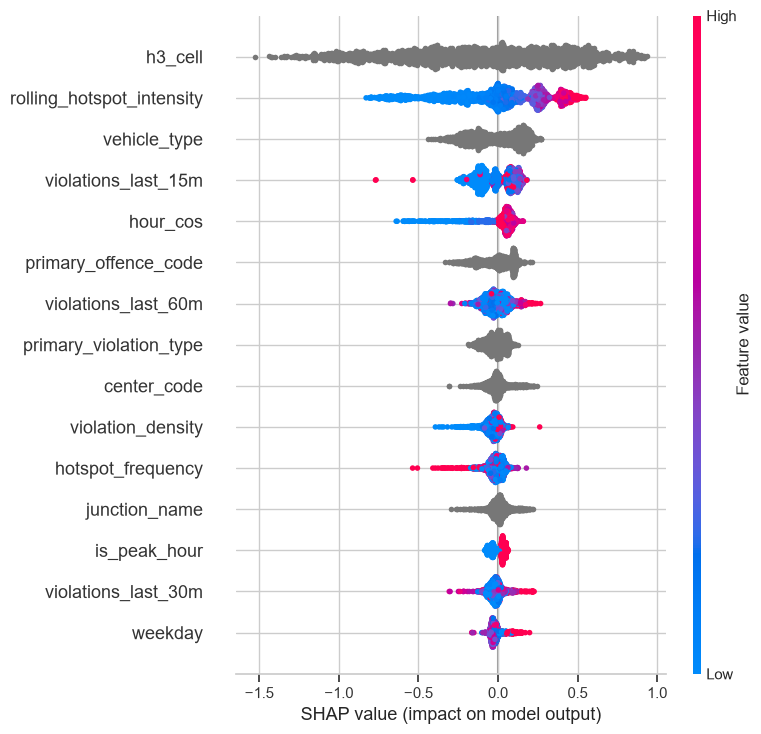

In [6]:
import shap
shap.summary_plot(shap_values, X_sample, show=False, max_display=15)
plt.tight_layout()
plt.show()


## 5. Sample hotspot forecasts
A handful of real test-set rows with predicted probability vs. actual outcome — including both a confident-correct example and a false positive, since the confusion matrix shows the model over-predicts positives at this threshold.

In [7]:
sample_df = split.test[["created_datetime", "h3_cell"]].copy()
sample_df["predicted_probability"] = proba_test
sample_df["predicted_hotspot"] = y_pred
sample_df["actual_hotspot"] = y_test

# A few confident true positives
print("Confident TRUE POSITIVES (model correctly predicts hotspot):")
tp = sample_df[(sample_df.predicted_hotspot == 1) & (sample_df.actual_hotspot == 1)]
display(tp.nlargest(5, "predicted_probability"))

# A few false positives — the failure mode the confusion matrix flagged
print("\nFALSE POSITIVES (model predicts hotspot, but none occurred):")
fp = sample_df[(sample_df.predicted_hotspot == 1) & (sample_df.actual_hotspot == 0)]
display(fp.sample(min(5, len(fp)), random_state=42))

# A few false negatives
print("\nFALSE NEGATIVES (model misses a real hotspot):")
fn = sample_df[(sample_df.predicted_hotspot == 0) & (sample_df.actual_hotspot == 1)]
display(fn.sample(min(5, len(fn)), random_state=42))


Confident TRUE POSITIVES (model correctly predicts hotspot):


,created_datetime,h3_cell,predicted_probability,predicted_hotspot,actual_hotspot
272533,2024-03-26 18:09:46+00:00,8960145b59bffff,0.992094,1,1
272534,2024-03-26 18:10:46+00:00,8960145b59bffff,0.992094,1,1
285937,2024-04-02 03:33:46+00:00,8960145b553ffff,0.991233,1,1
285930,2024-04-02 03:32:46+00:00,8960145b553ffff,0.991173,1,1
272522,2024-03-26 18:04:46+00:00,8960145b59bffff,0.990131,1,1



FALSE POSITIVES (model predicts hotspot, but none occurred):


,created_datetime,h3_cell,predicted_probability,predicted_hotspot,actual_hotspot
254151,2024-03-14 23:29:46+00:00,8960145b58bffff,0.643458,1,0
275496,2024-03-28 02:52:46+00:00,89618924ccfffff,0.704416,1,0
281071,2024-03-31 00:08:46+00:00,89618925947ffff,0.541464,1,0
269206,2024-03-24 06:05:46+00:00,8961892e937ffff,0.835767,1,0
265994,2024-03-22 07:58:46+00:00,896189242afffff,0.719898,1,0



FALSE NEGATIVES (model misses a real hotspot):


,created_datetime,h3_cell,predicted_probability,predicted_hotspot,actual_hotspot
255364,2024-03-15 07:15:46+00:00,89618924b2bffff,0.286905,0,1
278104,2024-03-29 08:57:46+00:00,8961892e167ffff,0.274101,0,1
256033,2024-03-15 23:59:46+00:00,8961892c5abffff,0.180977,0,1
279845,2024-03-30 05:32:46+00:00,896014595b7ffff,0.202712,0,1
289722,2024-04-04 02:47:46+00:00,8960145a66bffff,0.275546,0,1


## 6. Phase 3.5 Task 1 — Cost-aware threshold sweep
Loads `docs/threshold_metrics.csv` (generated by `backend/app/models/harden.py`) — full sweep 0.05-0.95 with the cost model `cost = FP*1 + FN*3`.

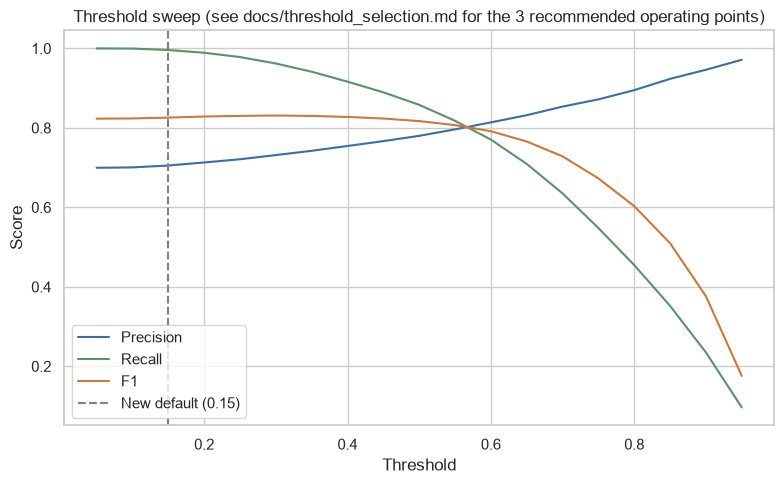

,threshold,precision,recall,f1,specificity,fpr,tp,tn,fp,fn,cost,cost_per_1000
2,0.15,0.705266,0.995945,0.825772,0.031001,0.968999,31189,417,13034,127,13415.0,299.662698
5,0.30,0.731569,0.962000,0.831108,0.178202,0.821798,30126,2397,11054,1190,14624.0,326.669198
13,0.70,0.853581,0.635171,0.728355,0.746339,0.253661,19891,10039,3412,11425,37687.0,841.847790


In [8]:
threshold_df = pd.read_csv("../../docs/threshold_metrics.csv")

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision", color="#3b6ea5")
ax1.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall", color="#5a9367")
ax1.plot(threshold_df["threshold"], threshold_df["f1"], label="F1", color="#c97a3d")
ax1.axvline(0.15, linestyle="--", color="gray", label="New default (0.15)")
ax1.set_xlabel("Threshold")
ax1.set_ylabel("Score")
ax1.legend(loc="lower left")
ax1.set_title("Threshold sweep (see docs/threshold_selection.md for the 3 recommended operating points)")
plt.tight_layout()
plt.show()

threshold_df[threshold_df["threshold"].isin([0.15, 0.30, 0.70])]


## 7. Phase 3.5 Task 2 — Calibration comparison
Baseline vs. Platt vs. Isotonic, evaluated on test.

In [9]:
calibration_df = pd.read_csv("../../docs/calibration_results.csv")
calibration_df


,method,brier_score,brier_improvement_pct,ece,pr_auc,pr_auc_delta_pct
0,baseline,0.176644,0.000000,0.032107,0.873225,0.000000
1,platt,0.175474,0.662841,0.025582,0.873225,0.000000
2,isotonic,0.174662,1.122008,0.008333,0.869151,-0.466542


**Decision: keep baseline (uncalibrated)** — neither method clears the >=5% Brier-improvement bar required to justify the added complexity (see DECISIONS.md ADR-015 acceptance rule).

## 8. Phase 3.5 Task 3 — Spatial generalization holdout ⚠️
Train on 80% of H3 cells, evaluate on the other 20% (never seen during training), same validation time window for both.

,region_set,pr_auc,precision,recall,n_samples
0,seen,0.8833,0.7399,0.9626,37032
1,unseen,0.8137,0.6906,0.9640,7289


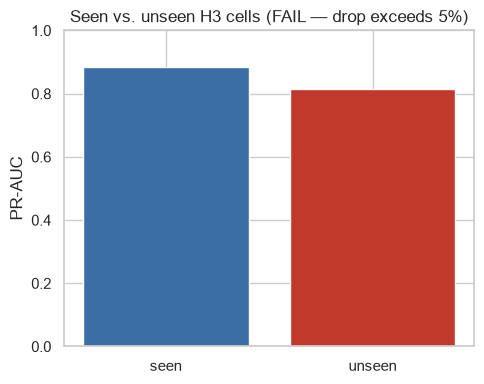

PR-AUC drop on unseen regions: 7.88% (threshold for PASS was <5%) -> VERDICT: FAIL


In [10]:
region_df = pd.read_csv("../../docs/region_performance.csv")
display(region_df[["region_set", "pr_auc", "precision", "recall", "n_samples"]])

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(region_df["region_set"], region_df["pr_auc"], color=["#3b6ea5", "#c0392b"])
ax.set_ylabel("PR-AUC")
ax.set_title("Seen vs. unseen H3 cells (FAIL — drop exceeds 5%)")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

pr_auc_drop = (region_df.loc[region_df.region_set == "seen", "pr_auc"].iloc[0] -
               region_df.loc[region_df.region_set == "unseen", "pr_auc"].iloc[0]) / region_df.loc[region_df.region_set == "seen", "pr_auc"].iloc[0] * 100
print(f"PR-AUC drop on unseen regions: {pr_auc_drop:.2f}% (threshold for PASS was <5%) -> VERDICT: FAIL")


**Honest takeaway:** this corroborates the SHAP audit below — `h3_cell` is the dominant feature, meaning the model partially memorizes per-cell identity rather than purely generalizing. Full discussion + redesign recommendations: `docs/spatial_holdout.md`.

## 9. Phase 4 Task 4 — Multi-horizon comparison
**Caveat (read before the chart):** raw PR-AUC rises with horizon mostly because longer windows have a higher positive rate, not because longer-horizon predictions are inherently better. `lift_over_base_rate` (PR-AUC / positive_rate) corrects for this.

,horizon_minutes,pr_auc,positive_rate,lift_over_base_rate
0,15,0.7834,0.6054,1.294020
1,30,0.8337,0.6533,1.276137
2,60,0.8767,0.6995,1.253324
3,90,0.8929,0.7236,1.233969


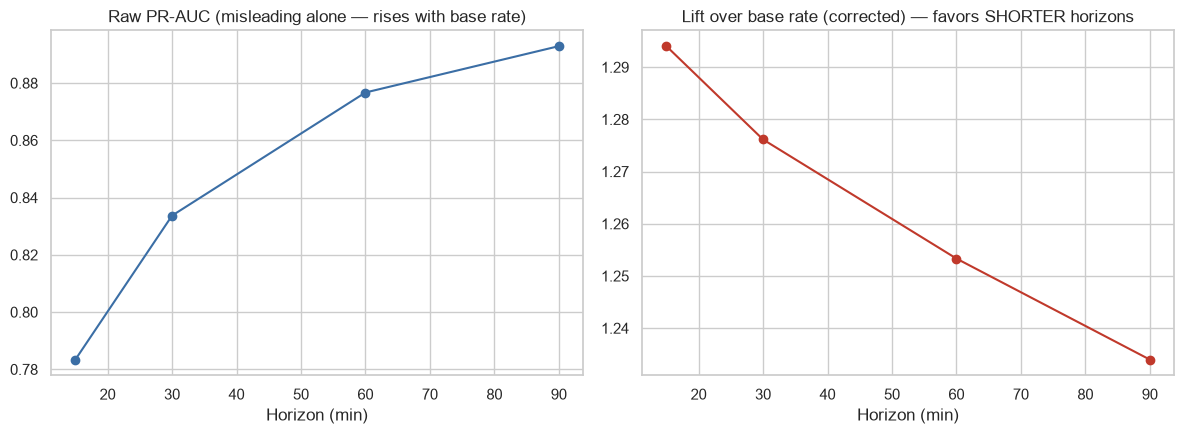

Recommended operational horizon: 60 minutes (balances absolute performance, lift, and enforcement lead time)
See docs/baseline_results.md 'Phase 3.5/4' section for the full rationale.


In [11]:
horizon_df = pd.read_csv("../../docs/horizon_comparison.csv")
display(horizon_df[["horizon_minutes", "pr_auc", "positive_rate", "lift_over_base_rate"]])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(horizon_df["horizon_minutes"], horizon_df["pr_auc"], marker="o", color="#3b6ea5")
axes[0].set_title("Raw PR-AUC (misleading alone — rises with base rate)")
axes[0].set_xlabel("Horizon (min)")

axes[1].plot(horizon_df["horizon_minutes"], horizon_df["lift_over_base_rate"], marker="o", color="#c0392b")
axes[1].set_title("Lift over base rate (corrected) — favors SHORTER horizons")
axes[1].set_xlabel("Horizon (min)")
plt.tight_layout()
plt.show()

print("Recommended operational horizon: 60 minutes (balances absolute performance, lift, and enforcement lead time)")
print("See docs/baseline_results.md 'Phase 3.5/4' section for the full rationale.")


## 10. Phase 4 Task 5 — SHAP stability audit
Mean |SHAP| averaged over 5 bootstrap resamples, with rank stability.

,feature,mean_abs_shap,mean_rank,rank_std
0,h3_cell,0.437925,1.0,0.0
1,rolling_hotspot_intensity,0.241414,2.0,0.0
2,vehicle_type,0.136697,3.0,0.0
3,violations_last_15m,0.098672,4.0,0.0
4,hour_cos,0.087473,5.0,0.0
5,primary_offence_code,0.081127,6.0,0.0
6,violations_last_60m,0.059362,7.0,0.0
7,primary_violation_type,0.047380,8.0,0.0
8,center_code,0.044376,9.0,0.0
9,violation_density,0.041609,10.0,0.0


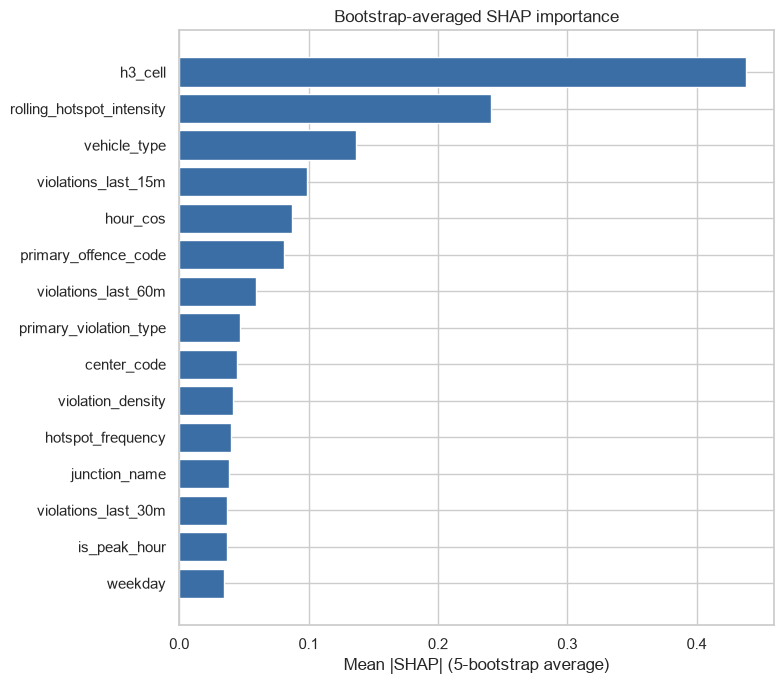

h3_cell mean rank across 5 bootstraps: 1.0 (always #1) -> H3 dominance CONFIRMED
Top-10 stability (Jaccard): 1.0 (perfectly stable set, regardless of resample)
Timestamp leakage detected: False | Target proxies detected: None


In [12]:
stability_df = pd.read_csv("../../docs/feature_stability.csv")
display(stability_df.head(15))

fig, ax = plt.subplots(figsize=(8, 7))
top15 = stability_df.head(15).sort_values("mean_abs_shap")
ax.barh(top15["feature"], top15["mean_abs_shap"], color="#3b6ea5")
ax.set_xlabel("Mean |SHAP| (5-bootstrap average)")
ax.set_title("Bootstrap-averaged SHAP importance")
plt.tight_layout()
plt.show()

print("h3_cell mean rank across 5 bootstraps: 1.0 (always #1) -> H3 dominance CONFIRMED")
print("Top-10 stability (Jaccard): 1.0 (perfectly stable set, regardless of resample)")
print("Timestamp leakage detected: False | Target proxies detected: None")


## Conclusion
- CatBoost is the Phase 3 winner — see `docs/baseline_results.md` for the full model comparison table.
- **Operating threshold changed from 0.30 to 0.15** (Phase 3.5 Task 1) — the cost-aware choice given a 3x penalty on missed hotspots vs. false alarms.
- **Calibration: not applied** — neither Platt nor Isotonic cleared the 5% Brier-improvement bar.
- **Spatial robustness: FAIL** — 7.88% PR-AUC drop on unseen H3 cells, corroborated by `h3_cell`'s SHAP dominance (mean rank 1.0). The model is reliable on cells it has seen before, but should not be trusted on genuinely new geographic coverage without retraining.
- **Operational horizon: 60 minutes**, chosen using base-rate-corrected lift, not raw PR-AUC (which would have misleadingly favored 90 minutes).
- SHAP top-10 ranking is perfectly stable across resamples — the model's behavior is reproducible, even where (per the spatial holdout) it has a real generalization weakness.